In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]


In [2]:
import matplotlib.pyplot as plt
from scripts.hamiltonian import *

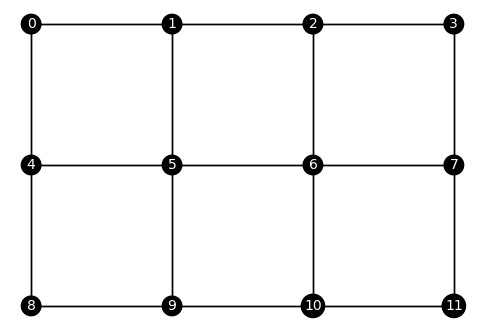

In [3]:
lattice = Lattice(4,3)
lattice.plot()

Converged after 1 iterations.


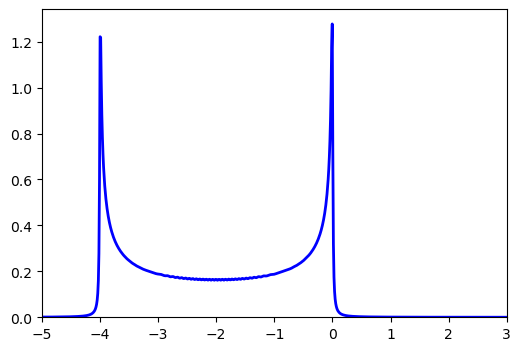

In [5]:
t = 1
mu = 2 * t
L = 512
gap = 0.0
U= 0 * t

lattice = Lattice(L,1,pbc=False)
H = Hamiltonian(lattice)
block = cp.zeros((4,4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap * s2
    block[2:, :2] = (-1j * gap * s2.T).conj()
    H.set_block(i,i, block)
    H.set_gap(i, gap)
    
for i, j in lattice.edges:
    block[:,:]=0
    block[:2, :2] = -t * s0
    block[2:, 2:] = t * s0
    H.set_block(i, j, block)
    H.set_block(j, i, block)
# eigval, eigvec = H.diagonalize()

gap0 = H.bdg_self_consistency(U,1e-6)
energies = cp.linspace(-6,4,1000) 
dos0_values = H.dos(energies, eta=0.01)

plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos0_values), color='blue', lw=2)
plt.ylim(0, None)
plt.xlim(-5,3)
plt.show()

In [6]:
lattice = Lattice(30,30,pbc=False)
gap_0 = 0.4
t = 1
mu = 2 * t
U = 1.5 * t

rows, cols = 512, 1

lattice = Lattice(rows, cols, pbc=False)

H = Hamiltonian(lattice)

block = cp.zeros((4,4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)
    H.set_gap(gap_0,i)
    
for i, j in lattice.edges:
    block[:,:]=0
    block[:2, :2] = -t * s0
    block[2:, 2:] = t * s0
    H.set_block(i, j, block)
    H.set_block(j, i, block)

gap = H.bdg_self_consistency(U,1e-6, max_iter=100)

Gap collapsed to zero.


In [7]:
energies = cp.linspace(-6,4,1000) 
dos_values = H.dos(energies, eta=0.0075, drop_matrix=False)

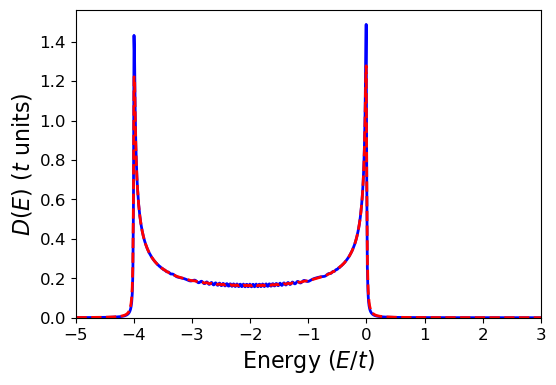

In [9]:
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values), color='blue', lw=2)
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos0_values), 'r--', lw=2)
plt.ylim(0, None)
plt.xlim(-5,3)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [10]:
from scripts.utils import tc_search

U = 2 * t
gap_0 = 1e-8
t = 1
mu = 2 * t
L=512
lattice = Lattice(L, 1, pbc=True)
T_up=1
T_dn=1e-12

Tc, Tc_list, T_high_list, T_low_list = tc_search(H, T_dn, T_up, U=U,tol=1e-6,max_iter=100)
print ("Critical Temperature Tc/t =", Tc / t)

Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Gap collapsed to zero.
Converged after 20 iterations
Critical Temperature Tc/t = 9.536753164052963e-07


[0.5000000000005, 0.25000000000075, 0.125000000000875, 0.0625000000009375, 0.03125000000096875, 0.015625000000984376, 0.007812500000992187, 0.003906250000996094, 0.001953125000998047, 0.0009765625009990236, 0.0004882812509995118, 0.0002441406259997559, 0.00012207031349987794, 6.103515724993897e-05, 3.051757912496948e-05, 1.5258790062484743e-05, 7.629395531242371e-06, 3.814698265621185e-06, 1.9073496328105927e-06, 9.536753164052963e-07]


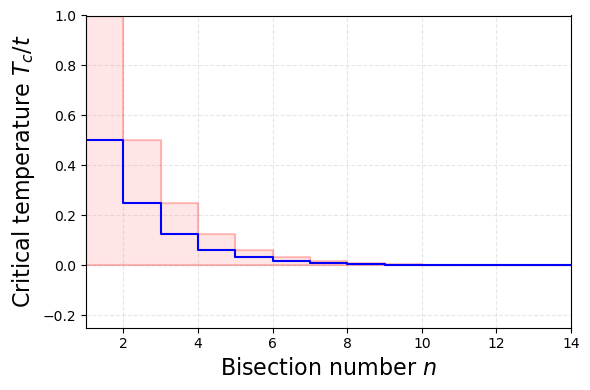

Final Tc: 9.536753164052963e-07


In [11]:
print(Tc_list)
plt.figure(figsize=(6,4))
plt.fill_between(range(1, 15), T_low_list[:14], T_high_list[:14], step='post', alpha=0.1, color='red')
plt.step(range(1, 15), np.array(T_high_list)[:14], where='post', color='red', alpha=0.2)
plt.step(range(1, 15), np.array(T_low_list)[:14], where='post', color='red', alpha=0.2)
plt.step(range(1, 15), np.array(Tc_list)[:14], where='post', color='blue')


plt.xlabel(r'Bisection number $n$', fontsize=16)
plt.ylabel(r'Critical temperature $T_c/t$', fontsize=16)
plt.xlim(1, 14)
plt.grid(True, alpha=0.3, ls='--')
plt.ylim(-0.25,1)
plt.tight_layout()
plt.show()
print(f"Final Tc: {Tc}")

In [ ]:
t = 1
mu = -2. * t
gap_p= cp.array([0.1, 0.1])
X,Y = 25,25
lattice = Lattice(X, Y, pbc_x=False, pbc_y=False)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    H.set_block(i,i, block)
    
for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j),gap_p = gap_p)
    block[0:2, 2:4] = gap_ij
    block[2:4, 0:2] = -gap_ij.T.conj()

    H.set_block(i,j, block)


energies = cp.linspace(-3,3,500) 
tdos, ldos_edge, ldos_bulk = H.ldos(energies, eta=0.04)

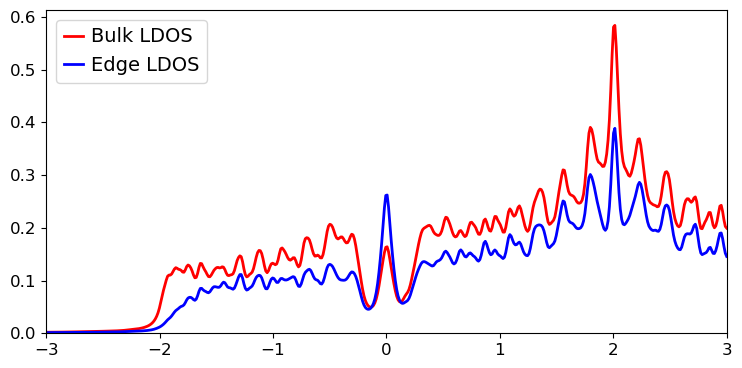

In [5]:
plt.figure(figsize=(8,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(ldos_bulk),label='Bulk LDOS', color='red', lw=2)
plt.plot(cp.asnumpy(energies), cp.asnumpy(ldos_edge),label='Edge LDOS', color='blue', lw=2)
# plt.plot(cp.asnumpy(energies), cp.asnumpy(tdos),label='Total DOS', color='black', lw=2)
plt.legend(fontsize=14,loc='upper left', handlelength=1.0, handletextpad=0.4)
plt.ylim(0,None)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-3,3)
# remove per-axis labels if you want only global ones
# plt.text(0.54, 0.04, "Energy $(E/t)$", ha="center", fontsize=16)
# plt.text(0.04, 0.5, "$D(E)$ ($t$ units)", va="center", rotation="vertical", fontsize=16)

plt.tight_layout(rect=[0.06, 0.055, 1, 1])
plt.ylim(0, None)
plt.xlim(-3, 3)
plt.show()

In [6]:
print(cp.allclose(H.matrix, H.matrix.conj().T, rtol=1e-7, atol=1e-12))


True
